In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Palatino", "Book Antiqua", "Baskerville", "Georgia", "DejaVu Serif"],
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "axes.edgecolor": "#CCCCCC",
    "grid.color": "#E6E6E6",
    "axes.titleweight": "bold",
})

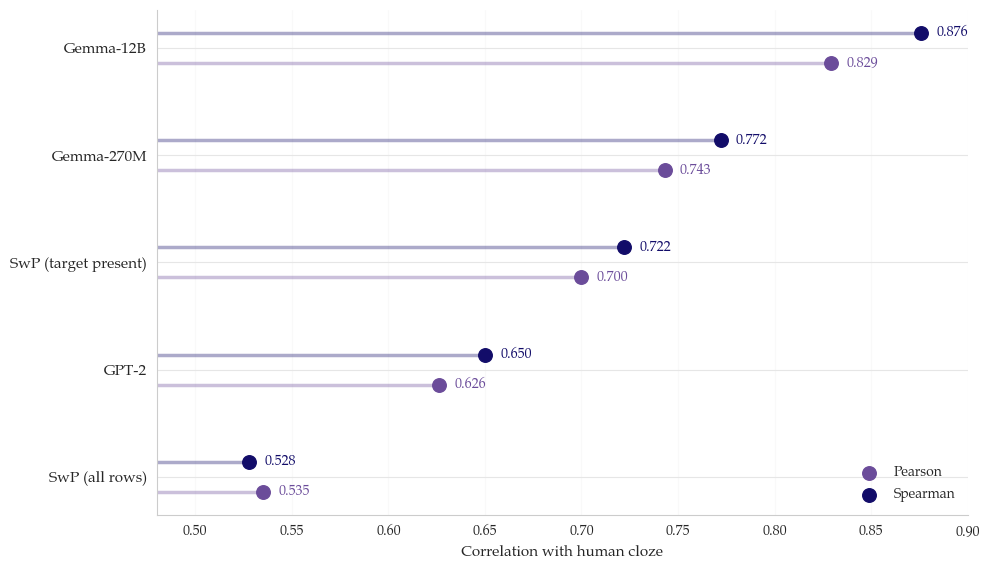

In [21]:
plot_df = pd.DataFrame({
    "Predictor": [
        "Gemma-12B",
        "Gemma-270M",
        "SwP (target present)",
        "GPT-2",
        "SwP (all rows)"
    ],
    "Pearson": [0.829, 0.743, 0.700, 0.626, 0.535],
    "Spearman": [0.876, 0.772, 0.722, 0.650, 0.528],
}).sort_values("Pearson", ascending=True).reset_index(drop=True)

PEARSON_COLOR = "#6B4C9A"
SPEARMAN_COLOR = "#120C69"  # navy

fig, ax = plt.subplots(figsize=(10, 5.8))

y = range(len(plot_df))
offset = 0.14

for i, row in plot_df.iterrows():
    ax.hlines(i - offset, xmin=0.48, xmax=row["Pearson"], color=PEARSON_COLOR, lw=2.5, alpha=0.35)
    ax.hlines(i + offset, xmin=0.48, xmax=row["Spearman"], color=SPEARMAN_COLOR, lw=2.5, alpha=0.35)

ax.scatter(plot_df["Pearson"], [i - offset for i in y], s=95, color=PEARSON_COLOR, label="Pearson", zorder=3)
ax.scatter(plot_df["Spearman"], [i + offset for i in y], s=95, color=SPEARMAN_COLOR, label="Spearman", zorder=3)

for i, row in plot_df.iterrows():
    ax.text(row["Pearson"] + 0.008, i - offset, f'{row["Pearson"]:.3f}', va="center", fontsize=10, color=PEARSON_COLOR)
    ax.text(row["Spearman"] + 0.008, i + offset, f'{row["Spearman"]:.3f}', va="center", fontsize=10, color=SPEARMAN_COLOR)

ax.set_yticks(list(y))
ax.set_yticklabels(plot_df["Predictor"], fontsize=11)
ax.set_xlabel("Correlation with human cloze", fontsize=11)
ax.set_xlim(0.48, 0.90)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", alpha=0.22)
ax.legend(frameon=False, loc="lower right")

plt.tight_layout()
plt.show()

C:\Users\PC\AppData\Local\Temp\ipykernel_28020\1795149641.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\PC\AppData\Local\Temp\ipykernel_28020\1795149641.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\PC\AppData\Local\Temp\ipykernel_28020\1795149641.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\PC\AppData\Local\Temp\ipykernel_28020\1795149641.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set 

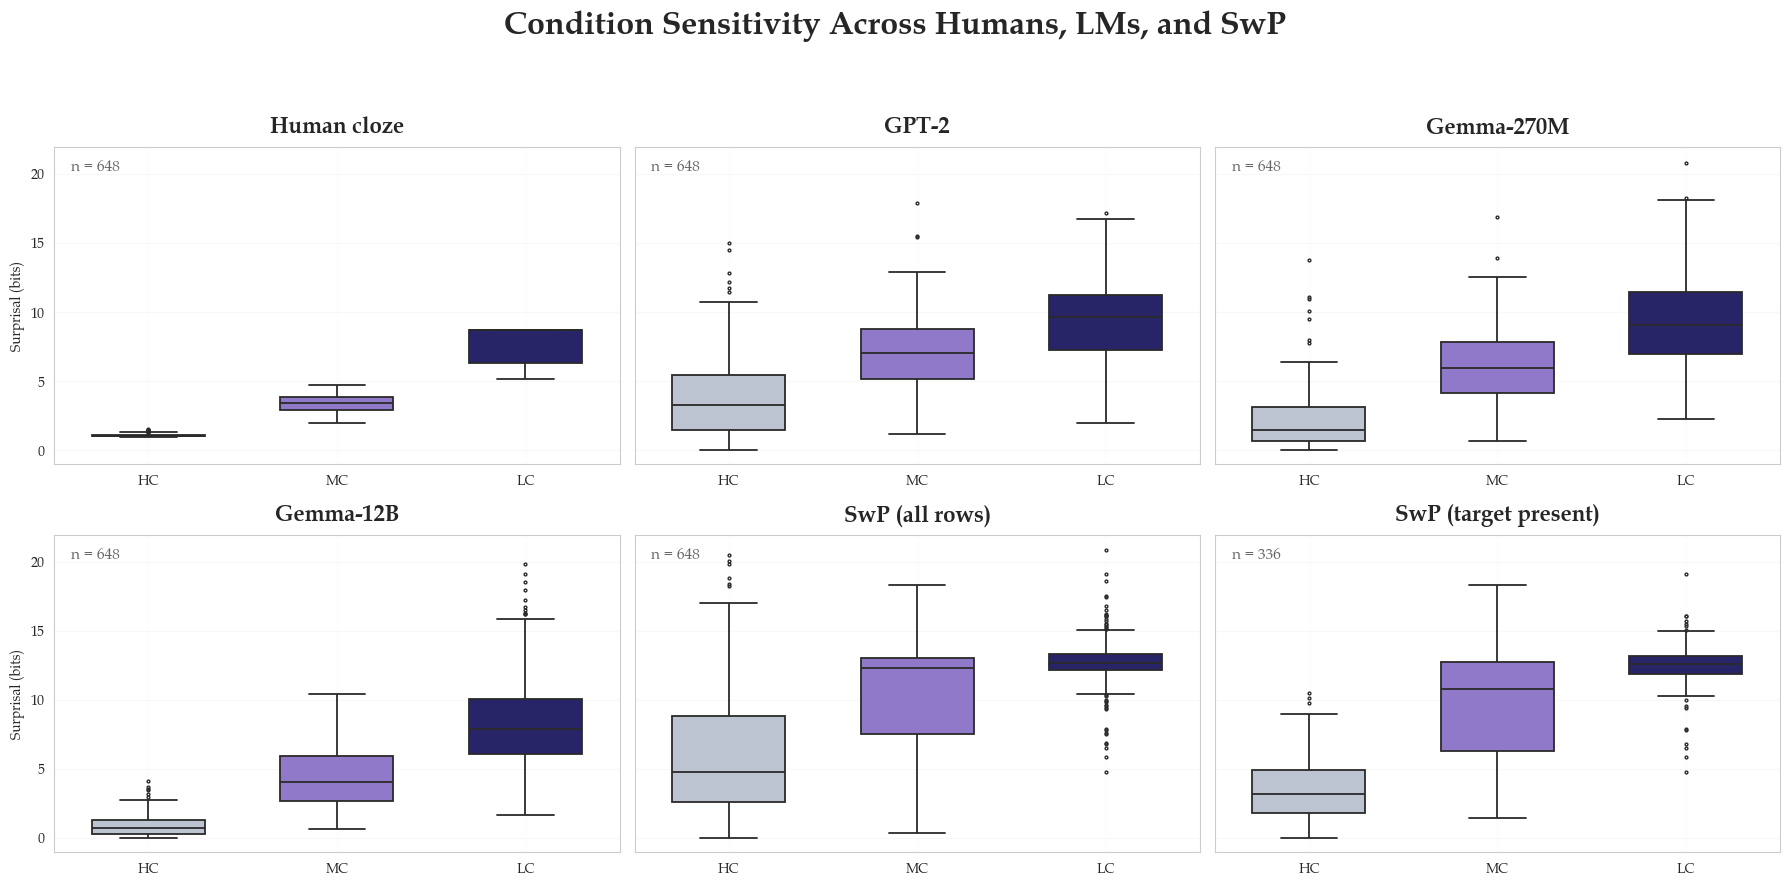

In [22]:
csv_path = "data/master_modeling_data_with_swp.csv"
df = pd.read_csv(csv_path)


item_df = (
    df.sort_values(["ITEM", "condition"])
      .drop_duplicates(subset=["ITEM", "condition"])
      .copy()
)

cond_order = ["HC", "MC", "LC"]
item_df["condition"] = pd.Categorical(item_df["condition"], categories=cond_order, ordered=True)

if "swp_target_missing" not in item_df.columns:
    if "swp_target_rank" in item_df.columns:
        item_df["swp_target_missing"] = item_df["swp_target_rank"].isna()
    else:
        raise ValueError("Need either 'swp_target_missing' or 'swp_target_rank'.")
    
COND_PALETTE = {
    "HC": "#B8C4D3",   
    "MC": "#8C6BD8",  
    "LC": "#1D1A72",  
}

panel_specs = [
    {
        "title": "Human cloze",
        "col": "cloze_surprisal",
        "data": item_df,
        "n": len(item_df),
    },
    {
        "title": "GPT-2",
        "col": "gpt2_uni_surprisal",
        "data": item_df,
        "n": len(item_df),
    },
    {
        "title": "Gemma-270M",
        "col": "gemma270m_uni_surprisal",
        "data": item_df,
        "n": len(item_df),
    },
    {
        "title": "Gemma-12B",
        "col": "gemma12b_uni_surprisal",
        "data": item_df,
        "n": len(item_df),
    },
    {
        "title": "SwP (all rows)",
        "col": "swp_surprisal_bits",
        "data": item_df,
        "n": len(item_df),
    },
    {
        "title": "SwP (target present)",
        "col": "swp_surprisal_bits",
        "data": item_df.loc[~item_df["swp_target_missing"]].copy(),
        "n": (~item_df["swp_target_missing"]).sum(),
    },
]

fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharey=True)
axes = axes.flatten()

for i, spec in enumerate(panel_specs):
    ax = axes[i]
    sub = spec["data"][["condition", spec["col"]]].dropna().copy()
    sub = sub.rename(columns={spec["col"]: "surprisal"})

    sns.boxplot(
        data=sub,
        x="condition",
        y="surprisal",
        order=cond_order,
        palette=COND_PALETTE,
        ax=ax,
        fliersize=2,
        linewidth=1.3,
        width=0.6,
    )

    ax.set_title(spec["title"], fontsize=16, pad=10)
    ax.set_xlabel("")
    ax.set_ylabel("Surprisal (bits)" if i in [0, 3] else "")
    ax.grid(axis="y", alpha=0.25)
    ax.grid(axis="x", alpha=0.08)

    ax.text(
        0.03, 0.96,
        f"n = {spec['n']}",
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=11, color="#666666"
    )


fig.suptitle(
    "Condition Sensitivity Across Humans, LMs, and SwP",
    fontsize=23, fontweight="bold", y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()